# CodeLab 6. Сверточная нейронная сеть на Keras


В этом задании вам предстоит:

- изучить API Keras для создания и обучения нейросети (классификатора изображений);  
- подобрать архитектуру сети и гиперпараметры для получения accuracy > 0.8

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models


## Загрузка датасета CIFAR-10 и нормализация данных

In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
num_classes = len(classes)

# Проверим размер входных и выходных векторов.
print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Training data shape:  (50000, 32, 32, 3)
Training labels shape:  (50000, 1)
Test data shape:  (10000, 32, 32, 3)
Test labels shape:  (10000, 1)


In [3]:
# Для сверточных сетей оставляем shape=(32,32,3), изменяем только формат данных uint8 -> fp64
X_train = X_train.astype(np.float64)
X_test = X_test.astype(np.float64)
y_train = y_train.flatten()
y_test = y_test.flatten()
# Проверим размер полученных данных
print('Training data shape: ', X_train.shape)
print('Test data shape: ', X_test.shape)
print('Training label shape: ', y_train.shape)
print('Test label shape: ', y_test.shape)

Training data shape:  (50000, 32, 32, 3)
Test data shape:  (10000, 32, 32, 3)
Training label shape:  (50000,)
Test label shape:  (10000,)


In [4]:
# Разделим данные на выборки train, val, test

num_training = 49000
num_validation = 1000
num_test = 1000
num_dev = 16

# Для валидации используем подвыборку train
mask = range(num_training, num_training + num_validation)
X_val = X_train[mask]
y_val = y_train[mask]

# На остальных данных из train будем тренировать модель
mask = range(num_training)
X_train = X_train[mask]
y_train = y_train[mask]

# Чтобы ускорить разработку, создадим также небольшую dev выборку 
mask = np.random.choice(num_training, num_dev, replace=False)
X_dev = X_train[mask]
y_dev = y_train[mask]

# Для тестирования используем оригинальную выборку test
mask = range(num_test)
X_test = X_test[mask]
y_test = y_test[mask]

print('Train data shape: ', X_train.shape)
print('Train labels shape: ', y_train.shape)
print('Validation data shape: ', X_val.shape)
print('Validation labels shape: ', y_val.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Train data shape:  (49000, 32, 32, 3)
Train labels shape:  (49000,)
Validation data shape:  (1000, 32, 32, 3)
Validation labels shape:  (1000,)
Test data shape:  (1000, 32, 32, 3)
Test labels shape:  (1000,)


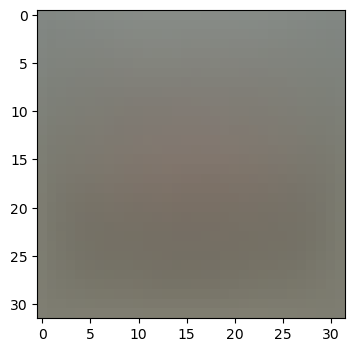

(49000, 32, 32, 3) (1000, 32, 32, 3) (1000, 32, 32, 3) (16, 32, 32, 3)


In [5]:
# Нормализуем значения яркости пикселей 
mean_image = np.mean(X_train, axis=0)

# визуализируем среднюю яркость
plt.figure(figsize=(4,4))
plt.imshow(mean_image.reshape((32,32,3)).astype('uint8')) 
plt.show()

# Вычтем средние значения яркости
X_train -= mean_image
X_val -= mean_image
X_test -= mean_image
X_dev -= mean_image


print(X_train.shape, X_val.shape, X_test.shape, X_dev.shape)

## LeNet architecture

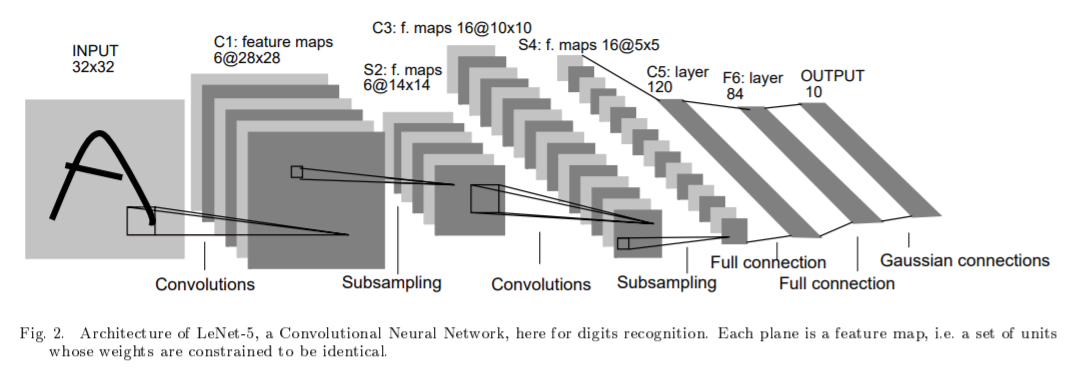

In [6]:
# Create LeNet instance
IMAGE_SHAPE = (32, 32, 3)
NUM_CLASSES = 10

lenet = tf.keras.models.Sequential()
lenet.add(tf.keras.layers.Input(shape=IMAGE_SHAPE))
lenet.add(tf.keras.layers.Conv2D(6, kernel_size=(5, 5), strides=(1, 1), activation='tanh', padding="same"))
lenet.add(tf.keras.layers.AveragePooling2D(pool_size=(2, 2), strides=(1, 1), padding='valid'))
lenet.add(tf.keras.layers.Conv2D(6, kernel_size=(5, 5), strides=(1, 1), activation='tanh', padding='valid'))
lenet.add(tf.keras.layers.AveragePooling2D(pool_size=(2, 2), strides=(2, 2), padding='valid'))
lenet.add(tf.keras.layers.Conv2D(16, kernel_size=(5, 5), strides=(1, 1), activation='tanh', padding='valid'))
lenet.add(tf.keras.layers.Flatten())
lenet.add(tf.keras.layers.Dense(84, activation='tanh'))
lenet.add(tf.keras.layers.Dense(NUM_CLASSES, activation='softmax'))    
lenet.compile(loss=tf.keras.losses.categorical_crossentropy, optimizer='SGD')

## Переобучим LeNet на малой выборке

In [7]:
# transform y indexes to sparse representation: [2] -> [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
y_dev_sparse = tf.keras.utils.to_categorical(y_dev, num_classes=NUM_CLASSES)

# Check initial loss and overfitting model with small dev dataset
hist = lenet.fit(X_dev, y_dev_sparse, batch_size=32, epochs=10)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 847ms/step - loss: 2.1337
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 1.9688
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 1.8097
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 1.6137
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 1.4501
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 1.3190
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 1.2068
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 1.0658
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 1.0331
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 1.0394


## Обучение LeNet на датасете Cifar10 c гиперпараметрами по умолчанию

In [8]:
BS = 64
LR = 1e-4
EPOCHS = 8

optimizer = keras.optimizers.Adam(learning_rate=LR)
lenet.compile(loss=keras.losses.categorical_crossentropy, optimizer=optimizer, metrics=['accuracy'])

y_train_sparse = keras.utils.to_categorical(y_train, num_classes=NUM_CLASSES)
history = lenet.fit(X_train, y_train_sparse, validation_split=0.2, batch_size=BS, epochs=EPOCHS)

Epoch 1/8
613/613 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.3055 - loss: 1.9570 - val_accuracy: 0.3741 - val_loss: 1.7797
Epoch 2/8
613/613 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.3998 - loss: 1.7359 - val_accuracy: 0.3966 - val_loss: 1.7281
Epoch 3/8
613/613 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.4209 - loss: 1.6810 - val_accuracy: 0.4062 - val_loss: 1.7036
Epoch 4/8
613/613 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.4411 - loss: 1.6297 - val_accuracy: 0.4216 - val_loss: 1.6764
Epoch 5/8
613/613 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.4477 - loss: 1.6089 - val_accuracy: 0.4214 - val_loss: 1.6563
Epoch 6/8
613/613 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.4599 - loss: 1.5690 - val_accuracy: 0.4346 - val_loss: 1.6364
Epoch 7/8
613/613 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.4691 - loss: 1.5359 - val_accuracy: 0.4436 - val_loss: 1.6064
Epoch 8/8
613/613 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.4816 - loss: 1.5073 - val_accuracy: 0.4491 -

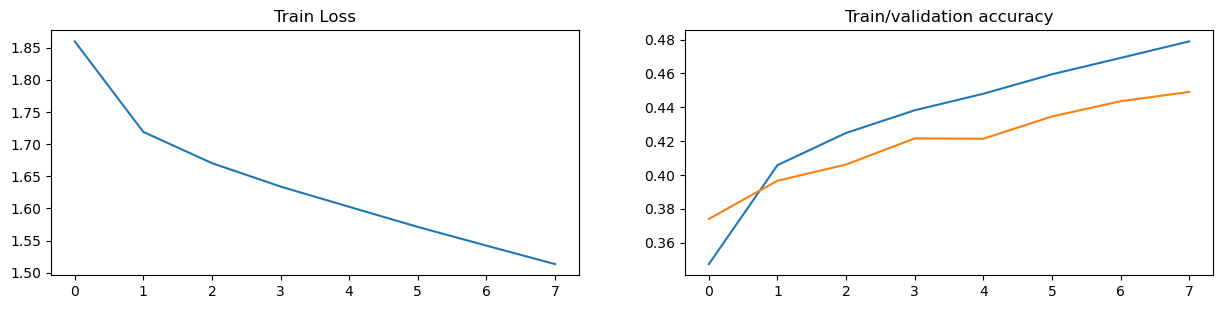

In [9]:
plt.figure(figsize=(15, 7))
plt.subplot(221)
plt.title("Train Loss")
plt.plot(history.history['loss'])
plt.subplot(222)
plt.title("Train/validation accuracy")
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

## Подбор архитектуры собственной сети и гиперпараметров обучения
Как видно из графиков, модель переобучилась. Поэкспериментируйте с гиперпараметрами и архитектурой, чтобы получить точность на тесте больше 80%

In [ ]:
# Experiment here!
y_val_sparse = keras.utils.to_categorical(y_val, num_classes=NUM_CLASSES)

class YourNameNet(models.Sequential):
    def __init__(self, input_shape, nb_classes):
        super().__init__()

        self.add(layers.Input(shape=input_shape))
        self.add(layers.Rescaling(1.0 / 255.0))
        self.add(layers.RandomFlip("horizontal"))
        self.add(layers.RandomTranslation(0.08, 0.08))

        for filters, dropout in [(32, 0.15), (64, 0.20), (128, 0.25), (256, 0.30)]:
            self.add(layers.Conv2D(filters, 3, padding="same", use_bias=False))
            self.add(layers.BatchNormalization())
            self.add(layers.Activation("relu"))
            self.add(layers.Conv2D(filters, 3, padding="same", use_bias=False))
            self.add(layers.BatchNormalization())
            self.add(layers.Activation("relu"))
            self.add(layers.MaxPooling2D())
            self.add(layers.Dropout(dropout))

        self.add(layers.GlobalAveragePooling2D())
        self.add(layers.Dense(256, activation="relu"))
        self.add(layers.Dropout(0.4))
        self.add(layers.Dense(nb_classes, activation="softmax"))

your_net = YourNameNet(IMAGE_SHAPE, NUM_CLASSES)
your_net.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.categorical_crossentropy,
    metrics=["accuracy"],
)

callbacks = [
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_accuracy", factor=0.5, patience=4, min_lr=1e-5, verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=10, restore_best_weights=True, verbose=1
    ),
]

history = your_net.fit(
    X_train,
    y_train_sparse,
    validation_data=(X_val, y_val_sparse),
    batch_size=128,
    epochs=60,
    callbacks=callbacks,
)


Epoch 1/60
383/383 ━━━━━━━━━━━━━━━━━━━━ 78s 181ms/step - accuracy: 0.3473 - loss: 1.8024 - val_accuracy: 0.2820 - val_loss: 2.1543 - learning_rate: 0.0010
Epoch 2/60
383/383 ━━━━━━━━━━━━━━━━━━━━ 62s 162ms/step - accuracy: 0.5925 - loss: 1.1457 - val_accuracy: 0.6020 - val_loss: 1.2020 - learning_rate: 0.0010
Epoch 3/60
383/383 ━━━━━━━━━━━━━━━━━━━━ 62s 163ms/step - accuracy: 0.6750 - loss: 0.9432 - val_accuracy: 0.6840 - val_loss: 1.0244 - learning_rate: 0.0010
Epoch 4/60
383/383 ━━━━━━━━━━━━━━━━━━━━ 64s 166ms/step - accuracy: 0.7147 - loss: 0.8259 - val_accuracy: 0.7010 - val_loss: 0.9898 - learning_rate: 0.0010
Epoch 5/60
383/383 ━━━━━━━━━━━━━━━━━━━━ 62s 162ms/step - accuracy: 0.7394 - loss: 0.7622 - val_accuracy: 0.7570 - val_loss: 0.7301 - learning_rate: 0.0010
Epoch 6/60
383/383 ━━━━━━━━━━━━━━━━━━━━ 61s 158ms/step - accuracy: 0.7615 - loss: 0.7033 - val_accuracy: 0.7900 - val_loss: 0.5984 - learning_rate: 0.0010
Epoch 7/60
383/383 ━━━━━━━━━━━━━━━━━━━━ 63s 164ms/step - accuracy: 0.7

In [ ]:
def multiclass_accuracy(y_pred, y_true):
  return np.mean(np.equal(y_true, np.argmax(y_pred, axis=1)))


y_test_pred = your_net.predict(X_test)
test_accuracy = multiclass_accuracy(y_test_pred, y_test)

print('YourNet test set accuracy: %f' % (test_accuracy, ))
assert test_accuracy > 0.8


In [ ]:
your_net.save('yournet_cifar10.h5')  